<a href="https://colab.research.google.com/github/tu25003-7491-cyber/EU_M_Math-Repository/blob/main/Chap03_Cm_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health 

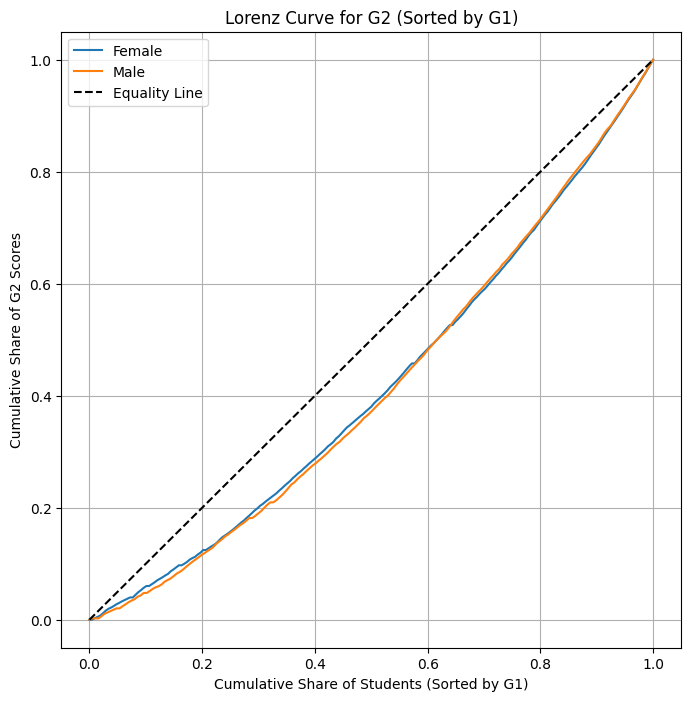

Female G1 Gini coefficient: 0.17237829508653402
Male G1 Gini coefficient: 0.17197351667939897


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CSV読み込み
df = pd.read_csv('/content/sample_data/student-mat.csv', sep=';')
print(df)

#男女別ソート
df_sorted_by_sex_g1 = df[['sex', 'G1']].sort_values(by='sex').reset_index(drop=True)
print(df_sorted_by_sex_g1)

def plot_lorenz_curve(data, label, ax):
    # G1でソートしてG2の累積比率を計算
    sorted_data = data.sort_values('G1')
    n = len(sorted_data)

    # 横軸: 人数の累積比率
    x = np.arange(n + 1) / n

    # 縦軸: G2の累積値の比率
    g2_values = sorted_data['G2'].values
    cumulative_g2 = np.cumsum(g2_values)
    y = np.insert(cumulative_g2 / cumulative_g2[-1], 0, 0)

    ax.plot(x, y, label=label)

fig, ax = plt.subplots(figsize=(8, 8))

# 男女別にプロット
plot_lorenz_curve(df[df['sex'] == 'F'], 'Female', ax)
plot_lorenz_curve(df[df['sex'] == 'M'], 'Male', ax)

# 完全平等線
ax.plot([0, 1], [0, 1], color='black', linestyle='--', label='Equality Line')

ax.set_title('Lorenz Curve for G2 (Sorted by G1)')
ax.set_xlabel('Cumulative Share of Students (Sorted by G1)')
ax.set_ylabel('Cumulative Share of G2 Scores')
ax.legend()
ax.grid(True)
plt.show()


def gini_coefficient(values):
    values = np.array(values)

    # 小さい順に並べる
    values = np.sort(values)

    n = len(values)

    # 累積順位を使ったジニ係数の計算式
    gini = (2 * np.sum((np.arange(1, n + 1)) * values)) / (n * np.sum(values)) - (n + 1) / n

    return gini


# 男女別にG1のジニ係数を計算
gini_female_g1 = gini_coefficient(df[df['sex'] == 'F']['G1'])
gini_male_g1 = gini_coefficient(df[df['sex'] == 'M']['G1'])

print('Female G1 Gini coefficient:', gini_female_g1)
print('Male G1 Gini coefficient:', gini_male_g1)